# ChargePoint Charging Logs EDA (Event-Level)

This notebook explores the synthetic EV charger event dataset used in the take-home assignment.

## Goals
- Understand the dataset shape and semantics (event-level rows inside sessions)
- Explore **distributions**, **correlations**, **outliers**, and **missing data patterns**
- Compare **station-level behavior**
- Inspect **temporal patterns** (including irregular logging intervals)
- Produce EDA findings that inform feature engineering and anomaly detection

> Note: Each row is an **event** within a charging session, not a full session summary.

## 1. Setup and Imports

In [1]:
import sys
print(sys.executable)

/Users/gokularamanc/Desktop/chargepoint-noc-anomaly-detection/.venv/bin/python


In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

SEED = 42

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print(f"Python executable: {sys.executable}")
print(f"pandas={pd.__version__}, numpy={np.__version__}")

Python executable: /Users/gokularamanc/Desktop/chargepoint-noc-anomaly-detection/.venv/bin/python
pandas=3.0.1, numpy=2.4.2


## 2. Data Loading and Basic Cleaning

In [3]:
def find_repo_root_and_data(start: Path):
    for candidate in [start, *start.parents]:
        root_csv = candidate / "charging_logs.csv"
        data_csv = candidate / "data" / "charging_logs.csv"
        if root_csv.exists():
            return candidate, root_csv
        if data_csv.exists():
            return candidate, data_csv
    raise FileNotFoundError(
        "Could not find charging_logs.csv (either at repo root or data/charging_logs.csv) "
        "from current working directory upward."
    )

REPO_ROOT, DATA_PATH = find_repo_root_and_data(Path.cwd())
print("REPO_ROOT:", REPO_ROOT)
print("DATA_PATH :", DATA_PATH)

REPO_ROOT: /Users/gokularamanc/Desktop/chargepoint-noc-anomaly-detection
DATA_PATH : /Users/gokularamanc/Desktop/chargepoint-noc-anomaly-detection/data/charging_logs.csv


In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df = df.rename(columns=lambda c: c.strip())

# Safe cleanup for EDA
df["error_code"] = pd.to_numeric(df["error_code"], errors="coerce")
df["message"] = df["message"].fillna("")

# Helper proxy/inspection flags (EDA only)
df["message_is_ok_like"] = df["message"].str.startswith("OK", na=False)
df["has_error_code"] = df["error_code"].fillna(0).ne(0)

# Sort for stable viewing; later cells may re-sort for session-specific ops
df = df.sort_values(["station_id", "session_id", "timestamp"]).reset_index(drop=True)

print(f"Rows, columns: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
display(df.head(8))

Rows, columns: (199566, 13)
Date range: 2024-01-01 00:05:42 to 2024-12-30 23:40:38


,station_id,timestamp,session_id,voltage,current,power_kw,temperature_c,duration_sec,energy_kwh,error_code,message,message_is_ok_like,has_error_code
0,STATION_0,2024-10-10 21:57:00,007b61dcd914,233.1600,31.7800,7.3780,40.0500,1,0.0020,0,OK,True,False
1,STATION_0,2024-10-10 21:57:04,007b61dcd914,312.7600,30.2900,6.9820,44.2400,44,0.0853,0,OK,True,False
2,STATION_0,2024-10-10 21:57:06,007b61dcd914,228.6400,30.9500,6.9390,43.1400,11,0.0212,0,OK,True,False
3,STATION_0,2024-10-10 21:57:08,007b61dcd914,229.6400,30.7400,7.1170,41.9800,37,0.0732,0,OK,True,False
4,STATION_0,2024-10-10 21:57:12,007b61dcd914,224.1700,33.9400,7.6160,44.8200,45,0.0952,0,OK,True,False
5,STATION_0,2024-10-10 21:57:20,007b61dcd914,231.8300,29.9200,6.9650,41.3500,56,0.1083,0,OK,True,False
6,STATION_0,2024-10-10 21:57:20,007b61dcd914,236.0800,30.7900,7.2330,43.0600,22,0.0442,0,OK,True,False
7,STATION_0,2024-10-10 21:57:21,007b61dcd914,231.1500,33.6900,7.8720,44.6700,33,0.0722,0,OK,True,False


## 3. Schema Audit and Dataset Summary

In [5]:
schema_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(dropna=True),
    }
).sort_index()

display(schema_summary)

,dtype,missing_count,missing_pct,unique_values
current,float64,0,0.0000,1891
duration_sec,int64,0,0.0000,60
energy_kwh,float64,0,0.0000,2185
error_code,int64,0,0.0000,5
has_error_code,bool,0,0.0000,2
message,str,0,0.0000,1178
message_is_ok_like,bool,0,0.0000,2
power_kw,float64,0,0.0000,5156
session_id,str,0,0.0000,4000
station_id,str,0,0.0000,20


In [6]:
dataset_summary = pd.Series(
    {
        "row_count": len(df),
        "column_count": df.shape[1],
        "unique_stations": df["station_id"].nunique(),
        "unique_sessions": df["session_id"].nunique(),
        "error_code_nonzero_rate_pct": float(df["has_error_code"].mean() * 100),
        "message_not_ok_like_rate_pct": float((~df["message_is_ok_like"]).mean() * 100),
    },
    name="value",
)

display(dataset_summary.to_frame())

,value
row_count,"199,566.0000"
column_count,13.0000
unique_stations,20.0000
unique_sessions,"4,000.0000"
error_code_nonzero_rate_pct,0.5557
message_not_ok_like_rate_pct,0.5557


## 4. Numeric Summaries and Fault/Message Patterns

In [7]:
numeric_cols = [
    "voltage",
    "current",
    "power_kw",
    "temperature_c",
    "duration_sec",
    "energy_kwh",
]

# EDA diagnostic: compare reported power vs V * I / 1000
df["power_from_vi_kw"] = (df["voltage"] * df["current"]) / 1000.0
df["power_vi_diff_kw"] = df["power_kw"] - df["power_from_vi_kw"]

num_summary = df[numeric_cols + ["power_from_vi_kw", "power_vi_diff_kw"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

display(num_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
voltage,"199,566.0000",228.6736,12.9863,88.7100,215.0400,219.0100,224.2100,227.9500,232.2400,242.7300,250.4300,390.9600
current,"199,566.0000",30.1559,3.7386,0.0000,22.8100,25.1700,28.2300,30.4200,32.4300,35.0000,36.6400,41.7000
power_kw,"199,566.0000",6.8574,1.2396,-8.9240,5.2110,5.7532,6.4390,6.9360,7.4160,8.0650,8.4870,9.6100
temperature_c,"199,566.0000",45.0982,6.0333,-8.4500,32.1600,35.2300,41.7500,45.8100,48.9200,52.4700,55.0300,93.9800
duration_sec,"199,566.0000",30.5061,17.3340,1.0000,1.0000,3.0000,16.0000,30.0000,46.0000,58.0000,60.0000,60.0000
energy_kwh,"199,566.0000",0.0599,0.0396,0.0013,0.0020,0.0066,0.0298,0.0584,0.0872,0.1143,0.1293,0.6979
power_from_vi_kw,"199,566.0000",6.8943,0.9310,0.0000,4.3058,5.7164,6.4349,6.9355,7.4198,8.0926,8.6321,13.7661
power_vi_diff_kw,"199,566.0000",-0.0368,1.2142,-17.8171,-2.5191,-0.1059,-0.0378,-0.0001,0.0376,0.1064,2.5657,8.9960


In [8]:
error_counts = (
    df["error_code"]
    .value_counts(dropna=False)
    .rename_axis("error_code")
    .to_frame("count")
)

message_counts = (
    df["message"]
    .value_counts(dropna=False)
    .head(15)
    .rename_axis("message")
    .to_frame("count")
)

print("Error code distribution:")
display(error_counts)

print("Top message values:")
display(message_counts)

print(f"Rows with error_code != 0: {int(df['has_error_code'].sum())} / {len(df)} ({df['has_error_code'].mean()*100:.4f}%)")

Error code distribution:


,count
error_code,
0,198457
303,286
404,276
101,276
202,271


Top message values:


,count
message,
OK,197285
Inconsistent metering data observed,236
Unexpected reboot during active session,226
Repeated handshake failures across multiple modules,217
Unknown hardware fault code: 0x7F3A,216
Severe voltage instability detected,214
OK (ref=0ff4ae),1
OK (ref=0414f6),1
OK (ref=65d689),1


Rows with error_code != 0: 1109 / 199566 (0.5557%)


## 5. Missing Data Analysis

In [9]:
missing_summary = pd.DataFrame(
    {
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100),
    }
).sort_values(["missing_count", "missing_pct"], ascending=False)

object_cols = df.select_dtypes(include=["object"]).columns.tolist()
blank_string_summary = pd.Series(
    {col: df[col].astype(str).str.strip().eq("").sum() for col in object_cols},
    name="blank_string_count",
).to_frame()

print("Missing value summary:")
display(missing_summary)

print("Blank string summary for object columns:")
display(blank_string_summary)

Missing value summary:


/var/folders/yq/kt6smx7j7xb3lkypq122rccm0000gn/T/ipykernel_42790/2665453102.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include=["object"]).columns.tolist()


,missing_count,missing_pct
station_id,0,0.0000
timestamp,0,0.0000
session_id,0,0.0000
voltage,0,0.0000
current,0,0.0000
power_kw,0,0.0000
temperature_c,0,0.0000
duration_sec,0,0.0000
energy_kwh,0,0.0000
error_code,0,0.0000


Blank string summary for object columns:


,blank_string_count
station_id,0
session_id,0
message,0


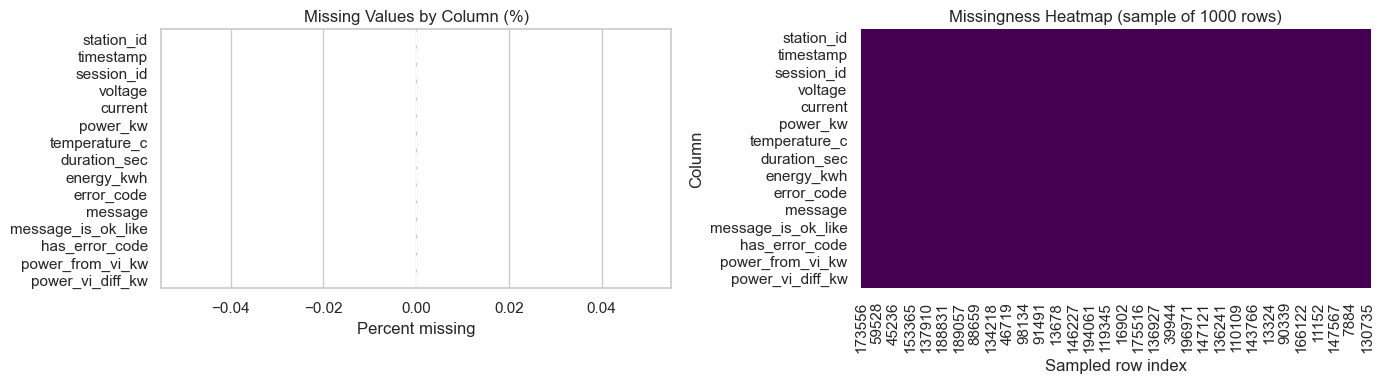

In [10]:
sample_n = min(1000, len(df))
missing_sample = df.sample(sample_n, random_state=SEED).isna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_df = missing_summary.reset_index().rename(columns={"index": "column"})
sns.barplot(data=plot_df, x="missing_pct", y="column", ax=axes[0], color="steelblue")
axes[0].set_title("Missing Values by Column (%)")
axes[0].set_xlabel("Percent missing")
axes[0].set_ylabel("")

sns.heatmap(missing_sample.T, cbar=False, ax=axes[1], cmap="viridis")
axes[1].set_title(f"Missingness Heatmap (sample of {sample_n} rows)")
axes[1].set_xlabel("Sampled row index")
axes[1].set_ylabel("Column")

plt.tight_layout()
plt.show()

## 6. Distribution Analysis

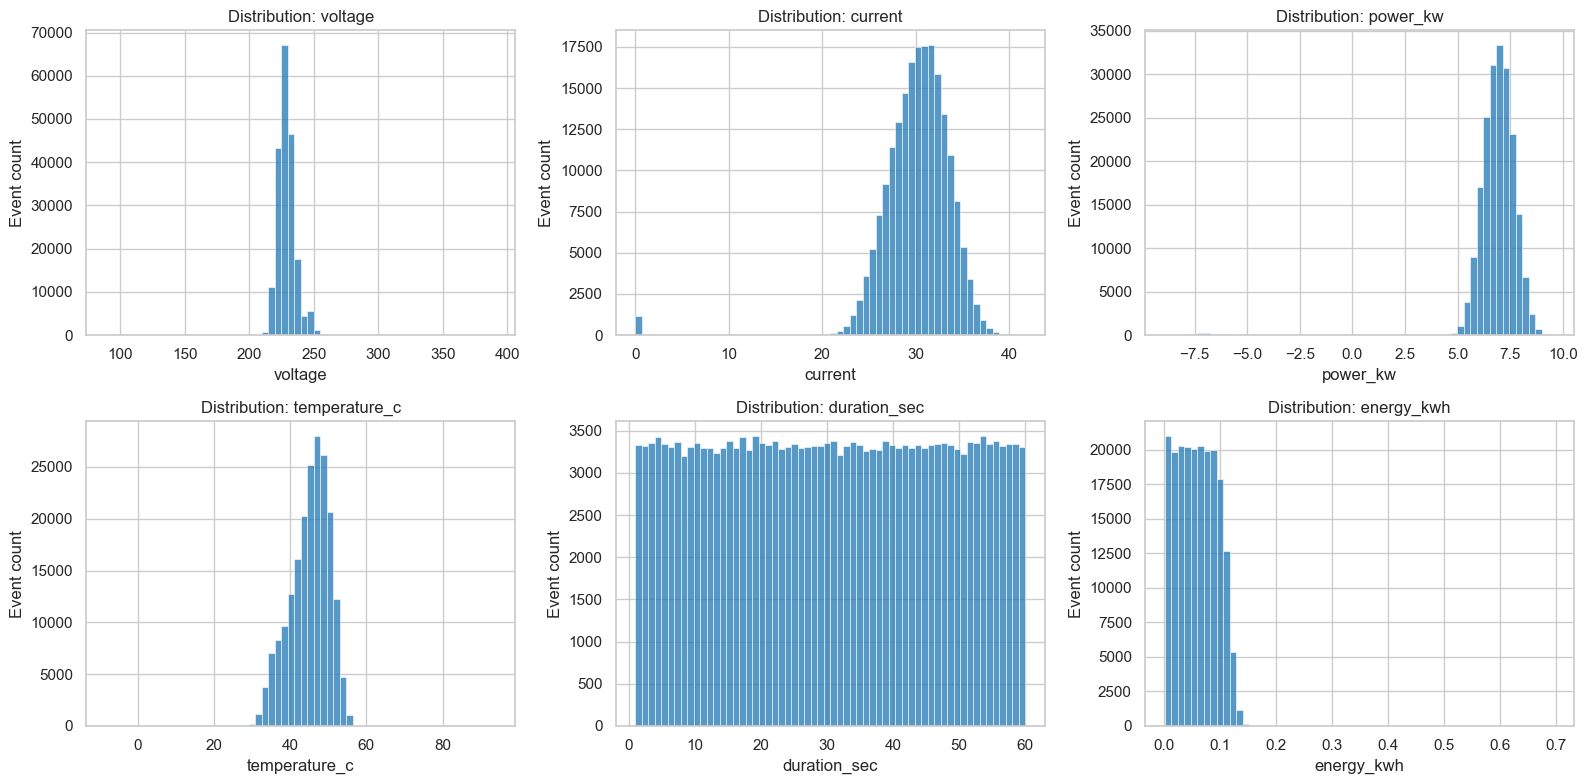

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], bins=60, ax=ax, color="tab:blue")
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Event count")

plt.tight_layout()
plt.show()

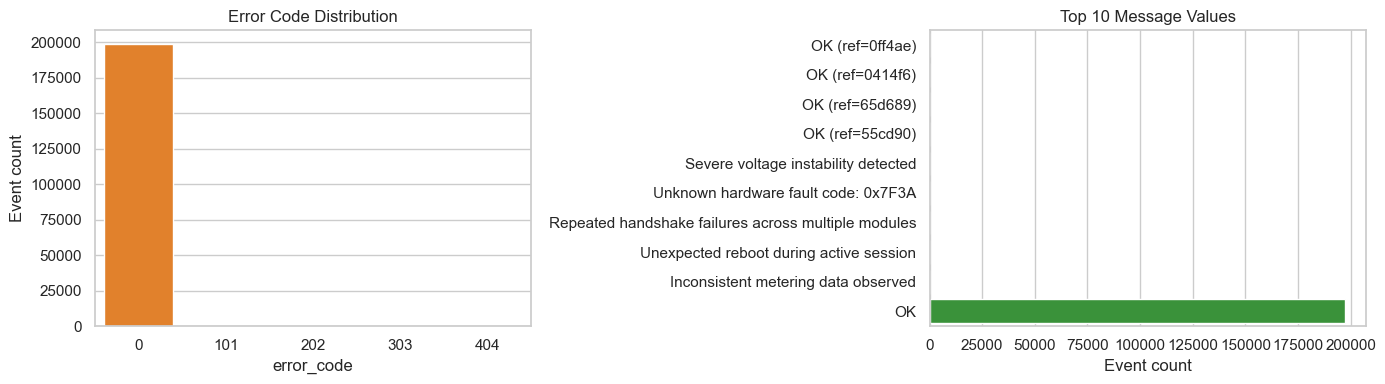

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

error_plot = df["error_code"].fillna(-1).astype(int).value_counts().sort_index().reset_index()
error_plot.columns = ["error_code", "count"]
sns.barplot(data=error_plot, x="error_code", y="count", ax=axes[0], color="tab:orange")
axes[0].set_title("Error Code Distribution")
axes[0].set_xlabel("error_code")
axes[0].set_ylabel("Event count")

msg_plot = df["message"].value_counts().head(10).sort_values(ascending=True).reset_index()
msg_plot.columns = ["message", "count"]
sns.barplot(data=msg_plot, x="count", y="message", ax=axes[1], color="tab:green")
axes[1].set_title("Top 10 Message Values")
axes[1].set_xlabel("Event count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

In [13]:
corr_cols = numeric_cols + ["power_from_vi_kw", "power_vi_diff_kw"]

pearson_corr = df[corr_cols].corr(method="pearson")
spearman_corr = df[corr_cols].corr(method="spearman")

print("Pearson correlation:")
display(pearson_corr)

print("Spearman correlation:")
display(spearman_corr)

Pearson correlation:


,voltage,current,power_kw,temperature_c,duration_sec,energy_kwh,power_from_vi_kw,power_vi_diff_kw
voltage,1.0000,-0.0327,0.0560,0.0336,-0.0009,0.0147,0.3874,-0.2399
current,-0.0327,1.0000,0.4117,0.1829,-0.0024,0.1135,0.9077,-0.2757
power_kw,0.0560,0.4117,1.0000,0.1365,-0.0038,0.0831,0.4025,0.7123
temperature_c,0.0336,0.1829,0.1365,1.0000,-0.0015,0.0374,0.1828,-0.0008
duration_sec,-0.0009,-0.0024,-0.0038,-0.0015,1.0000,0.8619,-0.0025,-0.0020
energy_kwh,0.0147,0.1135,0.0831,0.0374,0.8619,1.0000,0.1107,-0.0000
power_from_vi_kw,0.3874,0.9077,0.4025,0.1828,-0.0025,0.1107,1.0000,-0.3559
power_vi_diff_kw,-0.2399,-0.2757,0.7123,-0.0008,-0.0020,-0.0000,-0.3559,1.0000


Spearman correlation:


,voltage,current,power_kw,temperature_c,duration_sec,energy_kwh,power_from_vi_kw,power_vi_diff_kw
voltage,1.0000,0.0046,0.2534,0.1131,0.0012,0.0421,0.2841,-0.0317
current,0.0046,1.0000,0.9334,0.2663,-0.0024,0.1450,0.9384,-0.0148
power_kw,0.2534,0.9334,1.0000,0.2724,-0.0019,0.1522,0.9516,0.0940
temperature_c,0.1131,0.2663,0.2724,1.0000,-0.0022,0.0421,0.2668,0.0024
duration_sec,0.0012,-0.0024,-0.0019,-0.0022,1.0000,0.9767,-0.0026,0.0010
energy_kwh,0.0421,0.1450,0.1522,0.0421,0.9767,1.0000,0.1474,0.0144
power_from_vi_kw,0.2841,0.9384,0.9516,0.2668,-0.0026,0.1474,1.0000,-0.0478
power_vi_diff_kw,-0.0317,-0.0148,0.0940,0.0024,0.0010,0.0144,-0.0478,1.0000


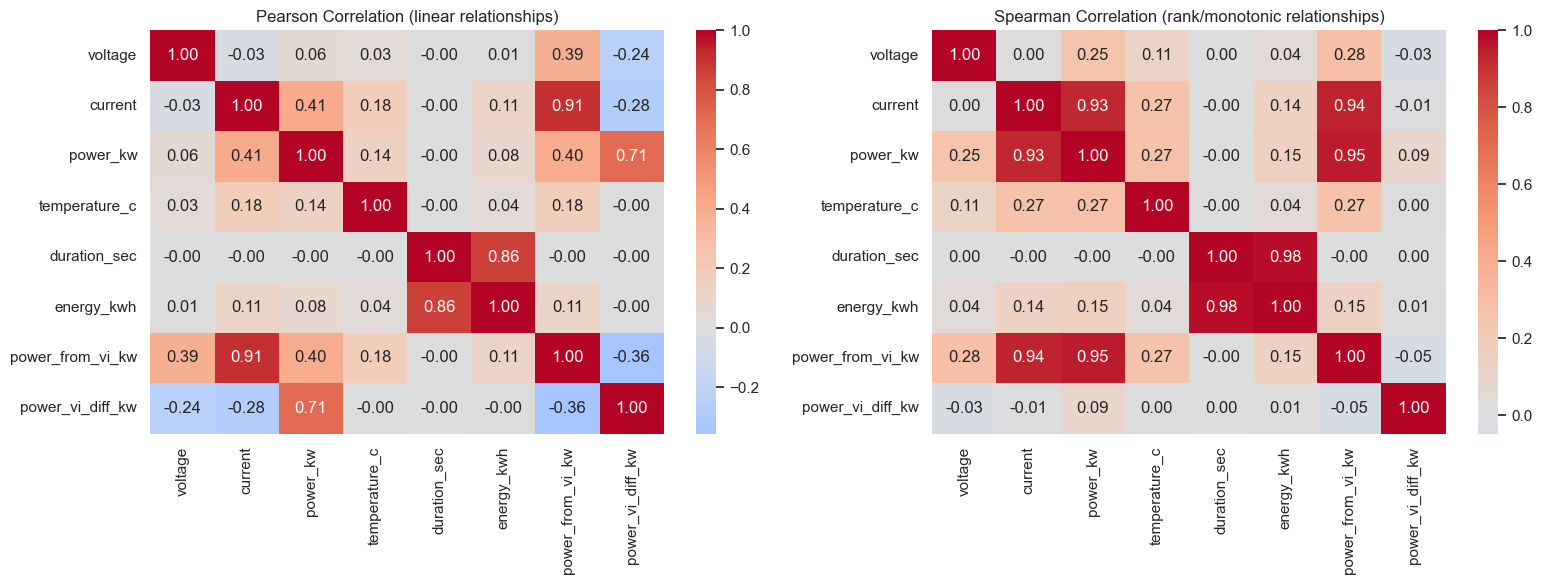

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Pearson Correlation (linear relationships)")

sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Spearman Correlation (rank/monotonic relationships)")

plt.tight_layout()
plt.show()

## 8. Temporal and Session-Context Features

In [15]:
# Sort by session/timestamp so temporal deltas are meaningful within each charging session
df = df.sort_values(["session_id", "timestamp", "station_id"]).reset_index(drop=True)
session_grp = df.groupby("session_id", sort=False)

# Time-based session features
df["time_delta_sec"] = session_grp["timestamp"].diff().dt.total_seconds()
df["time_delta_sec"] = df["time_delta_sec"].clip(lower=0)

df["session_event_index"] = session_grp.cumcount()
df["session_event_count"] = session_grp["timestamp"].transform("size")

raw_step_sec = session_grp["timestamp"].diff().dt.total_seconds().fillna(0).clip(lower=0)
df["session_elapsed_sec"] = raw_step_sec.groupby(df["session_id"]).cumsum()

# Delta features within session
for col in ["voltage", "current", "power_kw", "temperature_c", "energy_kwh"]:
    df[f"{col}_delta"] = session_grp[col].diff()

# Rate-of-change features (avoid divide-by-zero)
safe_dt = df["time_delta_sec"].replace({0: np.nan})
df["power_rate_kw_per_sec"] = df["power_kw_delta"] / safe_dt
df["temp_rate_c_per_sec"] = df["temperature_c_delta"] / safe_dt

# Calendar features for temporal EDA
df["event_hour"] = df["timestamp"].dt.hour
df["event_weekday"] = df["timestamp"].dt.day_name()
df["event_date"] = df["timestamp"].dt.date
df["event_month"] = df["timestamp"].dt.to_period("M").astype(str)

In [16]:
delta_summary = df["time_delta_sec"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

print("time_delta_sec summary (seconds, within session):")
display(delta_summary.to_frame().T)

preview_cols = [
    "session_id",
    "timestamp",
    "time_delta_sec",
    "session_event_index",
    "session_event_count",
    "voltage_delta",
    "power_kw_delta",
    "temperature_c_delta",
]
display(df[preview_cols].head(12))

time_delta_sec summary (seconds, within session):


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
time_delta_sec,"195,566.0000",8.9093,13.0147,0.0000,2.0000,5.0000,10.0000,21.0000,32.0000,65.0000,218.0000


,session_id,timestamp,time_delta_sec,session_event_index,session_event_count,voltage_delta,power_kw_delta,temperature_c_delta
0,000560d7ab9d,2024-07-23 05:33:23,NaN,0,45,NaN,NaN,NaN
1,000560d7ab9d,2024-07-23 05:33:27,4.0000,1,45,1.3800,-0.7090,1.9200
2,000560d7ab9d,2024-07-23 05:33:31,4.0000,2,45,-0.2500,0.3770,-1.7100
3,000560d7ab9d,2024-07-23 05:33:33,2.0000,3,45,5.1600,0.0950,-2.3300
4,000560d7ab9d,2024-07-23 05:33:35,2.0000,4,45,1.1600,-0.1200,6.4400
5,000560d7ab9d,2024-07-23 05:33:41,6.0000,5,45,-8.5800,0.2100,-6.3700
6,000560d7ab9d,2024-07-23 05:33:41,0.0000,6,45,4.8900,-0.6210,-3.9400
7,000560d7ab9d,2024-07-23 05:33:47,6.0000,7,45,-0.7100,0.5930,7.0100
8,000560d7ab9d,2024-07-23 05:33:48,1.0000,8,45,-2.5200,-0.2250,1.8000
9,000560d7ab9d,2024-07-23 05:33:49,1.0000,9,45,4.6500,1.4790,-3.4200


## 9. Outlier Analysis

In [17]:
def iqr_outlier_stats(series: pd.Series) -> dict:
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
        "outlier_pct": float(mask.mean() * 100),
    }

outlier_cols = numeric_cols + ["power_vi_diff_kw", "time_delta_sec"]

outlier_summary = pd.DataFrame(
    [{"feature": col, **iqr_outlier_stats(df[col])} for col in outlier_cols]
).sort_values("outlier_pct", ascending=False)

display(outlier_summary)

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
7,time_delta_sec,2.0000,10.0000,8.0000,-10.0000,22.0000,17429,8.7335
0,voltage,224.2100,232.2400,8.0300,212.1650,244.2850,9758,4.8896
6,power_vi_diff_kw,-0.0378,0.0376,0.0754,-0.1509,0.1507,7972,3.9947
3,temperature_c,41.7500,48.9200,7.1700,30.9950,59.6750,2473,1.2392
2,power_kw,6.4390,7.4160,0.9770,4.9735,8.8815,1618,0.8108
1,current,28.2300,32.4300,4.2000,21.9300,38.7300,1552,0.7777
5,energy_kwh,0.0298,0.0872,0.0574,-0.0563,0.1733,756,0.3788
4,duration_sec,16.0000,46.0000,30.0000,-29.0000,91.0000,0,0.0000


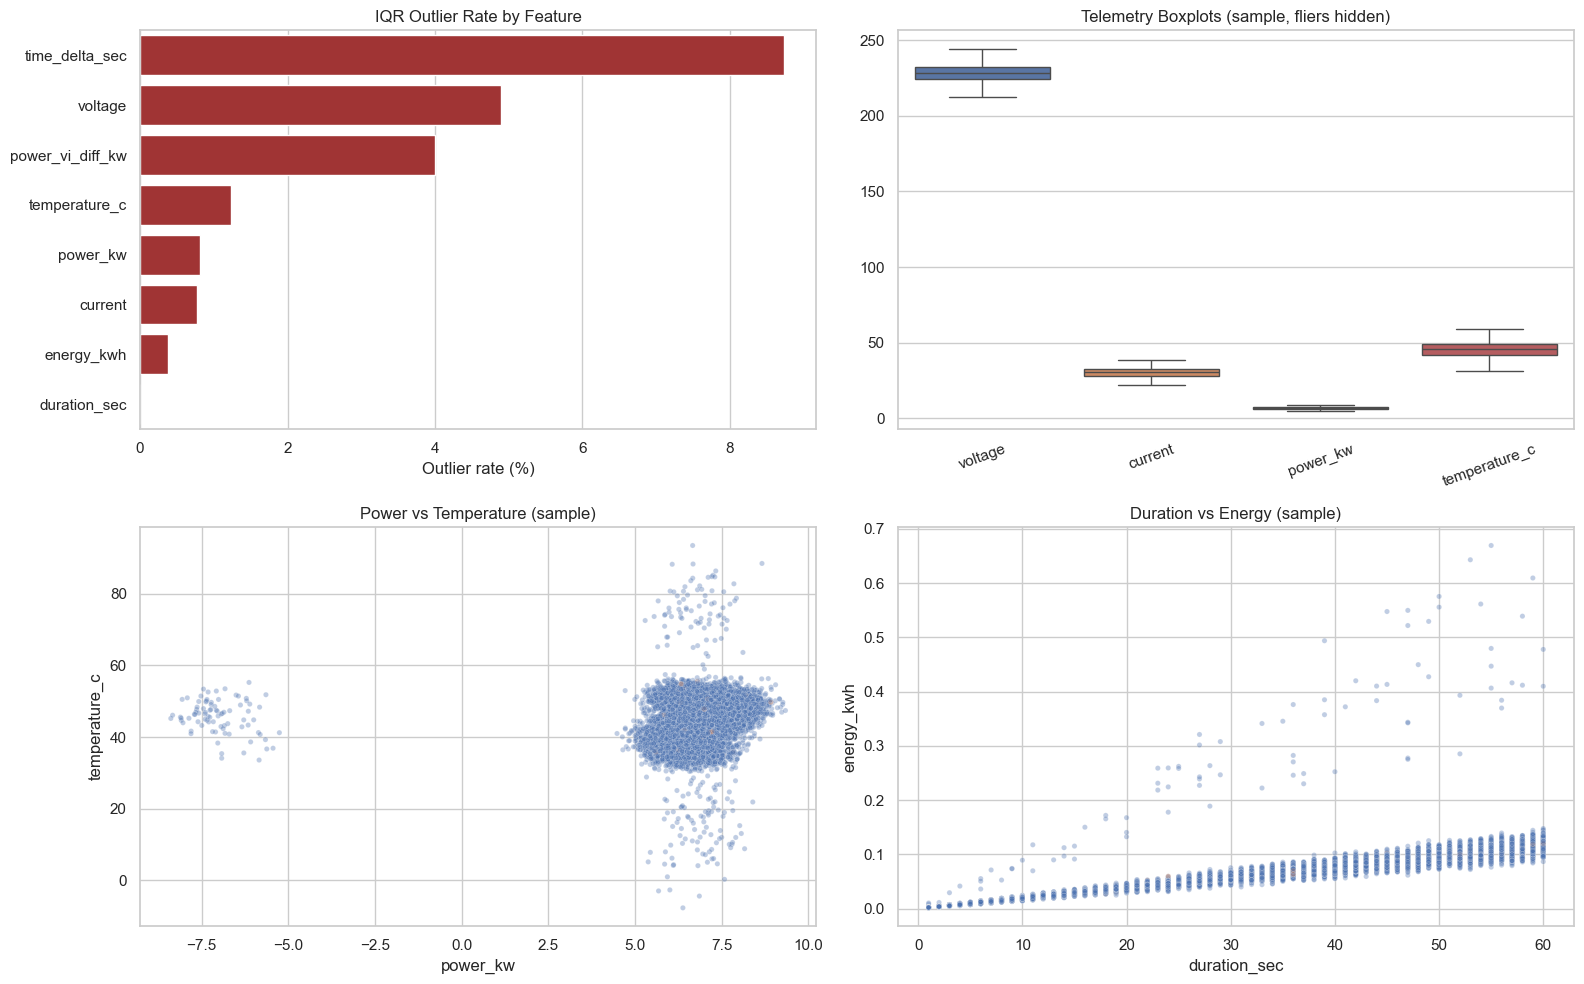

In [18]:
plot_sample = df.sample(min(15000, len(df)), random_state=SEED)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(
    data=outlier_summary.head(10),
    x="outlier_pct",
    y="feature",
    ax=axes[0, 0],
    color="firebrick"
)
axes[0, 0].set_title("IQR Outlier Rate by Feature")
axes[0, 0].set_xlabel("Outlier rate (%)")
axes[0, 0].set_ylabel("")

sns.boxplot(
    data=plot_sample[["voltage", "current", "power_kw", "temperature_c"]],
    ax=axes[0, 1],
    showfliers=False
)
axes[0, 1].set_title("Telemetry Boxplots (sample, fliers hidden)")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.scatterplot(
    data=plot_sample,
    x="power_kw",
    y="temperature_c",
    hue="has_error_code",
    alpha=0.35,
    s=14,
    ax=axes[1, 0],
    legend=False,
)
axes[1, 0].set_title("Power vs Temperature (sample)")

sns.scatterplot(
    data=plot_sample,
    x="duration_sec",
    y="energy_kwh",
    hue="has_error_code",
    alpha=0.35,
    s=14,
    ax=axes[1, 1],
    legend=False,
)
axes[1, 1].set_title("Duration vs Energy (sample)")

plt.tight_layout()
plt.show()

## 10. Station-Level Behavior Analysis

In [19]:
station_summary = (
    df.groupby("station_id", dropna=False)
    .agg(
        event_rows=("station_id", "size"),
        unique_sessions=("session_id", "nunique"),
        voltage_mean=("voltage", "mean"),
        current_mean=("current", "mean"),
        power_mean=("power_kw", "mean"),
        power_median=("power_kw", "median"),
        temperature_mean=("temperature_c", "mean"),
        temperature_p95=("temperature_c", lambda s: s.quantile(0.95)),
        error_rate=("has_error_code", "mean"),
        non_ok_message_rate=("message_is_ok_like", lambda s: 1 - s.mean()),
    )
    .sort_values("error_rate", ascending=False)
)

display(station_summary)

,event_rows,unique_sessions,voltage_mean,current_mean,power_mean,power_median,temperature_mean,temperature_p95,error_rate,non_ok_message_rate
station_id,,,,,,,,,,
STATION_4,10227,200,219.9721,28.7297,6.2777,6.3560,51.6878,55.0900,0.0071,0.0071
STATION_16,9935,200,234.4501,29.8100,6.9246,7.0200,45.1730,48.5900,0.0069,0.0069
STATION_18,10298,200,226.7079,26.2224,5.9089,5.9710,39.7032,43.0200,0.0069,0.0069
STATION_6,9983,200,246.3550,26.8053,6.5732,6.6340,42.6681,46.0000,0.0067,0.0067
STATION_2,9879,200,233.6088,33.4889,7.8092,7.8860,49.0402,52.4710,0.0067,0.0067
STATION_14,9847,200,229.8497,32.8673,7.5121,7.5860,50.3375,53.6900,0.0062,0.0062
STATION_17,10063,200,233.3039,27.3068,6.3439,6.4110,50.5963,54.0200,0.0061,0.0061
STATION_15,9906,200,225.4997,27.6266,6.1934,6.2695,41.8794,45.2900,0.0059,0.0059
STATION_19,9802,200,235.5130,31.3145,7.3262,7.4070,46.6520,49.9600,0.0056,0.0056


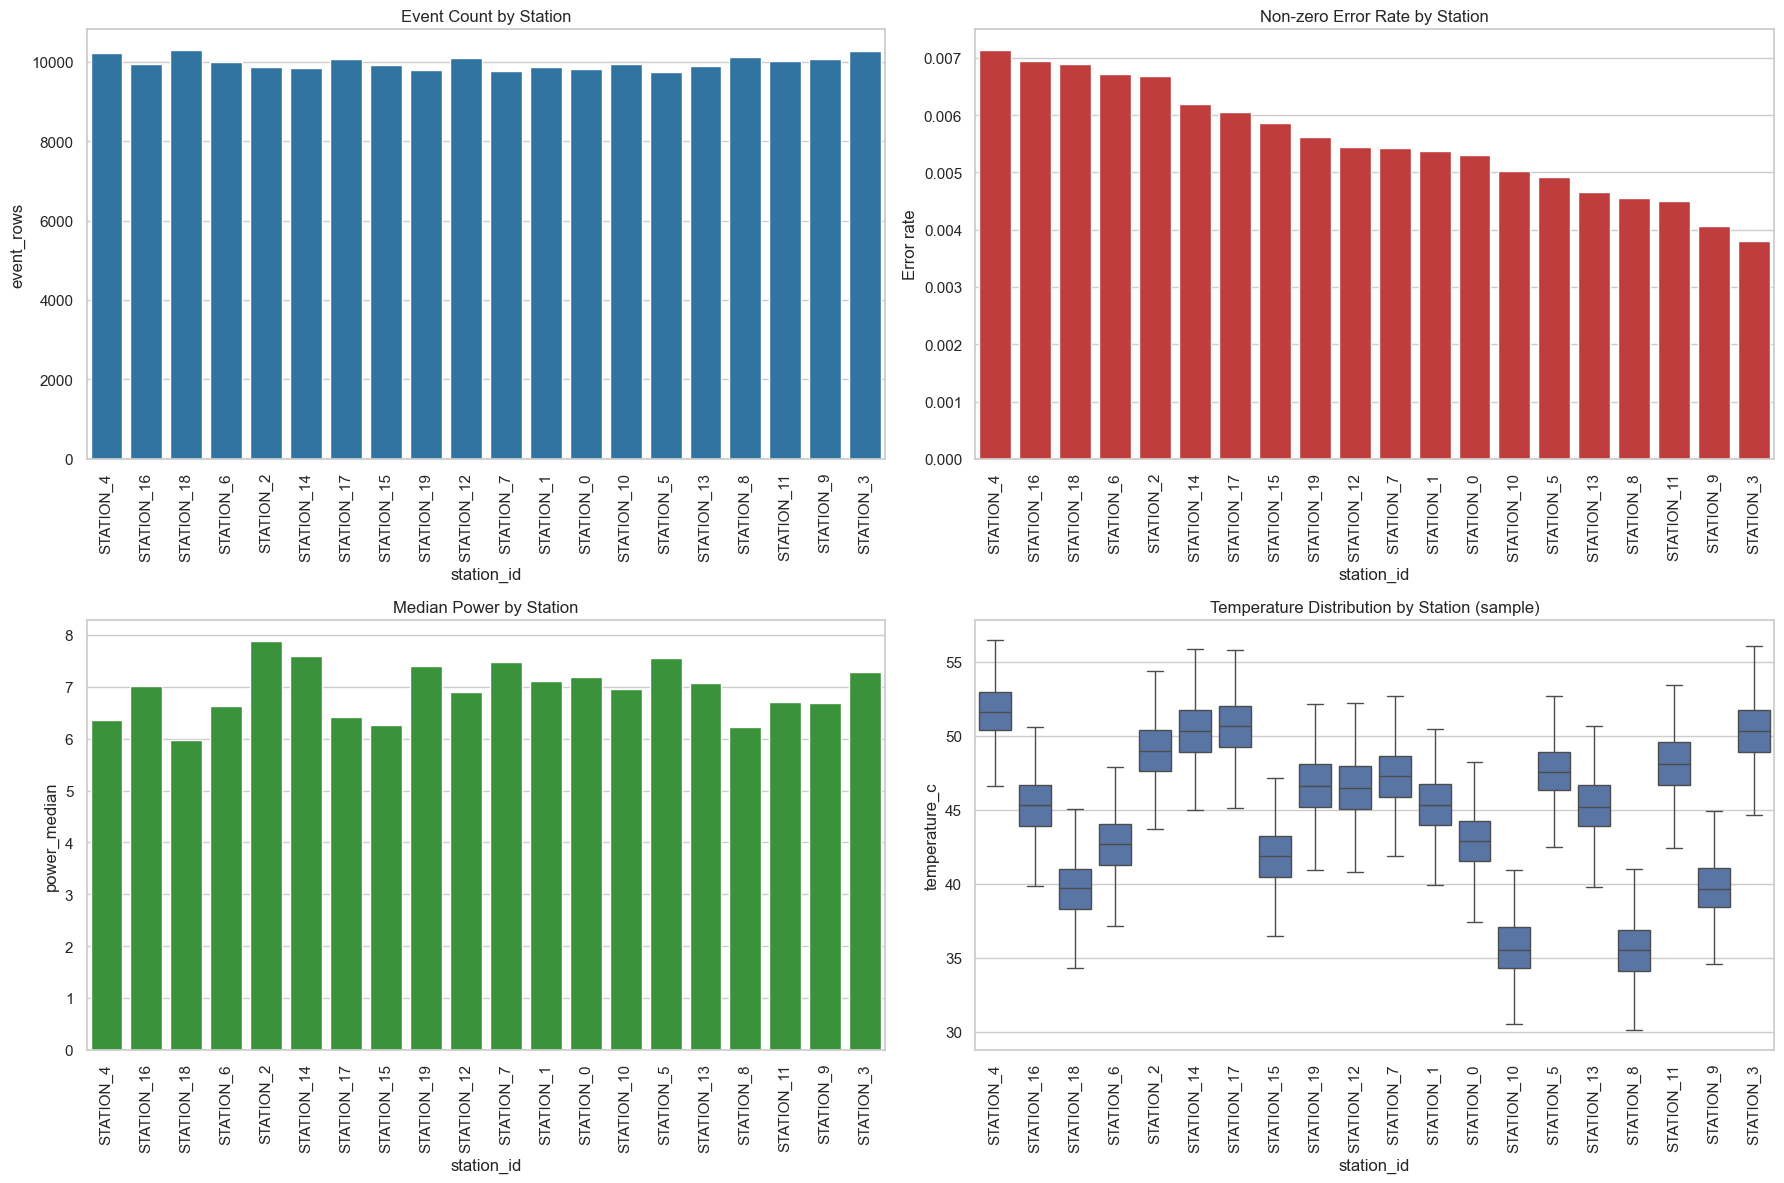

In [20]:
station_plot_order = station_summary.index.tolist()
station_sample = df.sample(min(30000, len(df)), random_state=SEED)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(
    data=station_summary.reset_index(),
    x="station_id",
    y="event_rows",
    order=station_plot_order,
    ax=axes[0, 0],
    color="tab:blue",
)
axes[0, 0].set_title("Event Count by Station")
axes[0, 0].tick_params(axis="x", rotation=90)

sns.barplot(
    data=station_summary.reset_index(),
    x="station_id",
    y="error_rate",
    order=station_plot_order,
    ax=axes[0, 1],
    color="tab:red",
)
axes[0, 1].set_title("Non-zero Error Rate by Station")
axes[0, 1].tick_params(axis="x", rotation=90)
axes[0, 1].set_ylabel("Error rate")

sns.barplot(
    data=station_summary.reset_index(),
    x="station_id",
    y="power_median",
    order=station_plot_order,
    ax=axes[1, 0],
    color="tab:green",
)
axes[1, 0].set_title("Median Power by Station")
axes[1, 0].tick_params(axis="x", rotation=90)

sns.boxplot(
    data=station_sample,
    x="station_id",
    y="temperature_c",
    order=station_plot_order,
    ax=axes[1, 1],
    showfliers=False,
)
axes[1, 1].set_title("Temperature Distribution by Station (sample)")
axes[1, 1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

## 11. Temporal Patterns

In [21]:
daily_summary = (
    df.groupby(pd.Grouper(key="timestamp", freq="D"))
    .agg(
        event_rows=("station_id", "size"),
        error_rate=("has_error_code", "mean"),
        avg_power_kw=("power_kw", "mean"),
        avg_temperature_c=("temperature_c", "mean"),
    )
    .reset_index()
)

hourly_summary = (
    df.groupby("event_hour")
    .agg(
        event_rows=("station_id", "size"),
        error_rate=("has_error_code", "mean"),
        avg_power_kw=("power_kw", "mean"),
    )
    .reset_index()
)

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_summary = (
    df.groupby("event_weekday")
    .agg(
        event_rows=("station_id", "size"),
        error_rate=("has_error_code", "mean"),
    )
    .reindex(weekday_order)
    .reset_index()
)

month_hour_heatmap = (
    df.assign(month_num=df["timestamp"].dt.month)
    .pivot_table(
        index="month_num",
        columns="event_hour",
        values="station_id",
        aggfunc="count",
        fill_value=0
    )
)

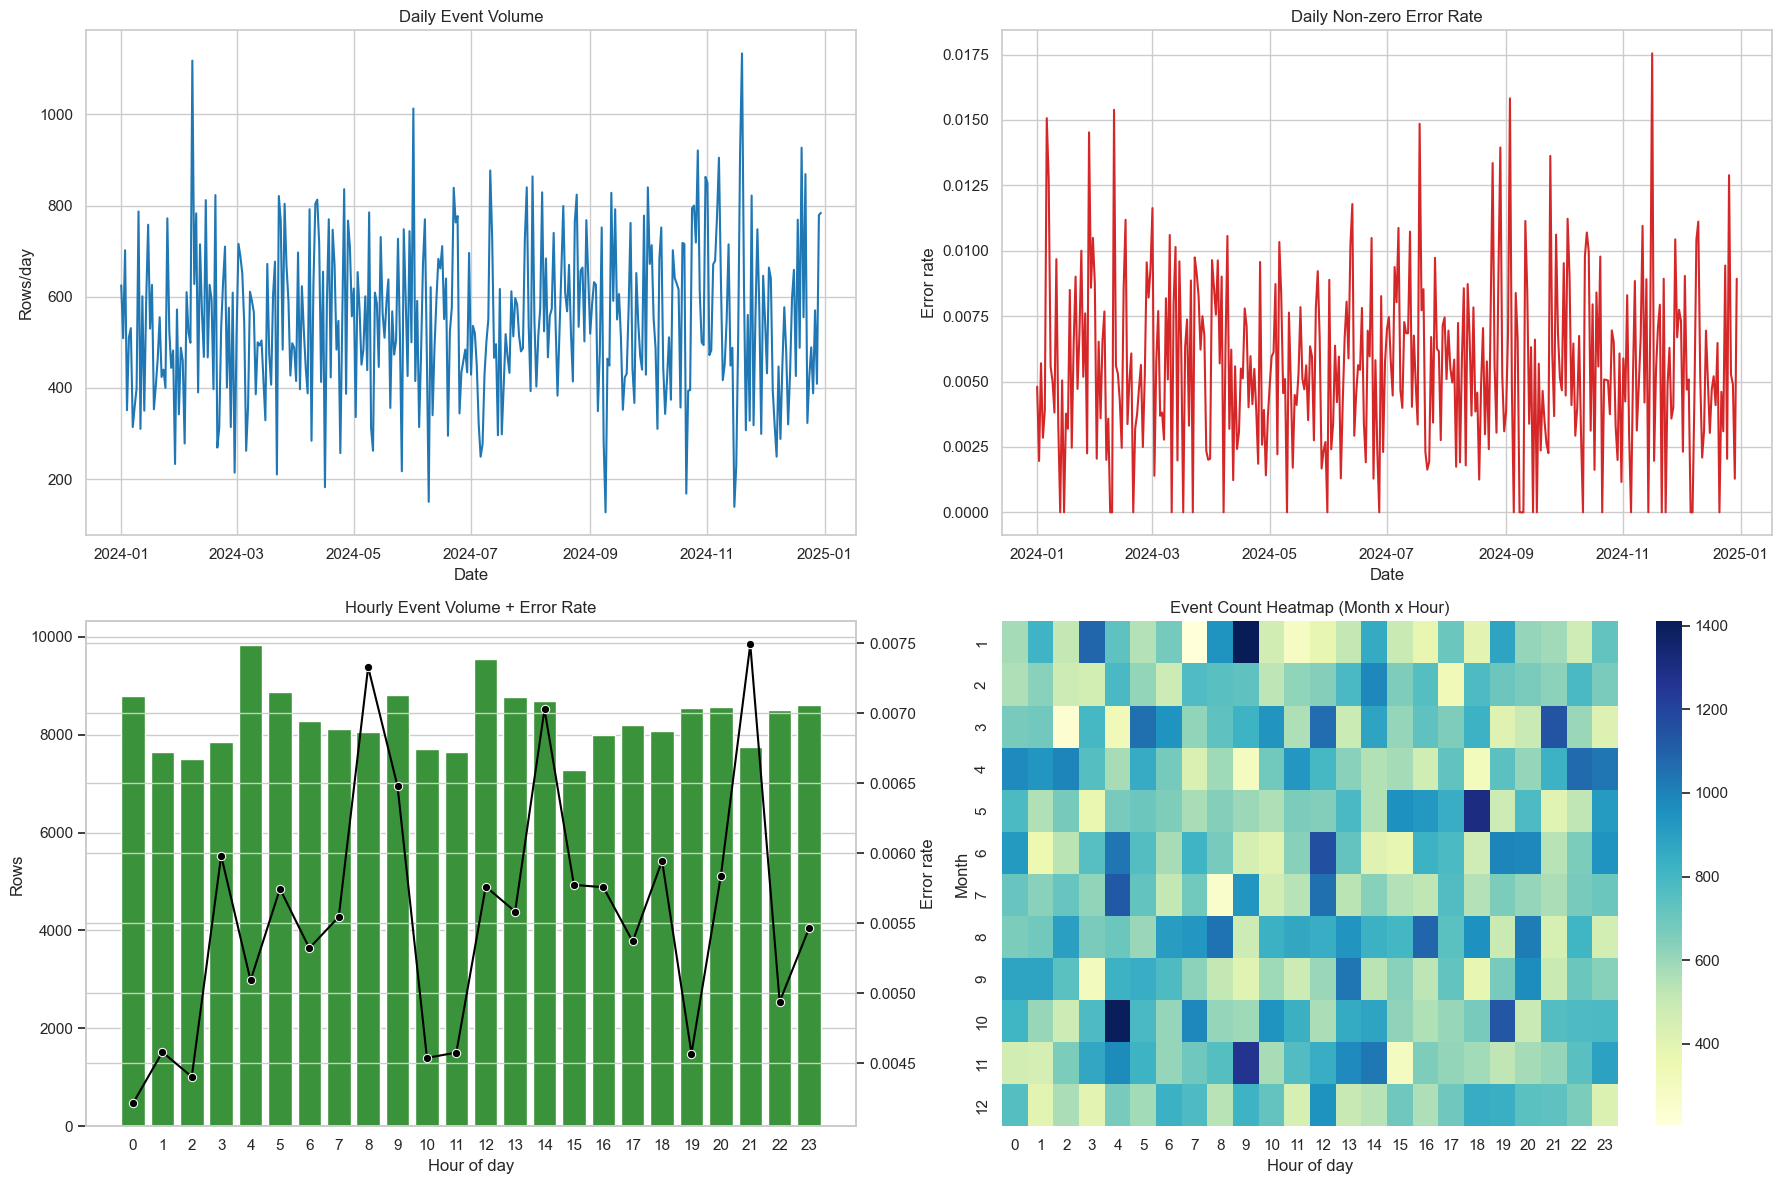

Weekday summary:


,event_weekday,event_rows,error_rate
0,Monday,28658,0.0052
1,Tuesday,28066,0.0057
2,Wednesday,28980,0.0055
3,Thursday,28296,0.0055
4,Friday,28594,0.0055
5,Saturday,27845,0.0060
6,Sunday,29127,0.0055


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.lineplot(data=daily_summary, x="timestamp", y="event_rows", ax=axes[0, 0], color="tab:blue")
axes[0, 0].set_title("Daily Event Volume")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Rows/day")

sns.lineplot(data=daily_summary, x="timestamp", y="error_rate", ax=axes[0, 1], color="tab:red")
axes[0, 1].set_title("Daily Non-zero Error Rate")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Error rate")

sns.barplot(data=hourly_summary, x="event_hour", y="event_rows", ax=axes[1, 0], color="tab:green")
ax2 = axes[1, 0].twinx()
sns.lineplot(data=hourly_summary, x="event_hour", y="error_rate", ax=ax2, color="black", marker="o")
axes[1, 0].set_title("Hourly Event Volume + Error Rate")
axes[1, 0].set_xlabel("Hour of day")
axes[1, 0].set_ylabel("Rows")
ax2.set_ylabel("Error rate")

sns.heatmap(month_hour_heatmap, cmap="YlGnBu", ax=axes[1, 1])
axes[1, 1].set_title("Event Count Heatmap (Month x Hour)")
axes[1, 1].set_xlabel("Hour of day")
axes[1, 1].set_ylabel("Month")

plt.tight_layout()
plt.show()

print("Weekday summary:")
display(weekday_summary)

## 12. Session Behavior and Logging Interval Analysis

In [23]:
session_event_counts = df.groupby("session_id").size().rename("event_rows")
session_gap_diversity = df.groupby("session_id")["time_delta_sec"].nunique(dropna=True).rename("unique_gap_sizes")
gap_freq = df["time_delta_sec"].dropna().astype(int).value_counts().sort_index().rename("count")

# Pick one session with many proxy-error rows (if available)
error_counts_by_session = df.groupby("session_id")["has_error_code"].sum().sort_values(ascending=False)
example_session_id = error_counts_by_session.index[0]
example_session = df[df["session_id"] == example_session_id].sort_values("timestamp").copy()

sampling_summary = pd.Series(
    {
        "median_time_delta_sec": df["time_delta_sec"].median(),
        "p95_time_delta_sec": df["time_delta_sec"].quantile(0.95),
        "max_time_delta_sec": df["time_delta_sec"].max(),
        "zero_gap_share_pct": df["time_delta_sec"].eq(0).mean() * 100,
        "sessions_with_multiple_gap_sizes_pct": (session_gap_diversity.fillna(0) > 1).mean() * 100,
    },
    name="value",
)

display(sampling_summary.to_frame())
print("Example session_id selected:", example_session_id)
display(example_session.head(10))

,value
median_time_delta_sec,5.0000
p95_time_delta_sec,32.0000
max_time_delta_sec,218.0000
zero_gap_share_pct,8.6227
sessions_with_multiple_gap_sizes_pct,100.0000


Example session_id selected: 9e86104900e4


,station_id,timestamp,session_id,voltage,current,power_kw,temperature_c,duration_sec,energy_kwh,error_code,message,message_is_ok_like,has_error_code,power_from_vi_kw,power_vi_diff_kw,time_delta_sec,session_event_index,session_event_count,session_elapsed_sec,voltage_delta,current_delta,power_kw_delta,temperature_c_delta,energy_kwh_delta,power_rate_kw_per_sec,temp_rate_c_per_sec,event_hour,event_weekday,event_date,event_month
123169,STATION_16,2024-07-18 05:09:06,9e86104900e4,235.9400,27.2600,6.4290,48.1100,11,0.0196,0,OK,True,False,6.4317,-0.0027,NaN,0,68,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,Thursday,2024-07-18,2024-07
123170,STATION_16,2024-07-18 05:09:10,9e86104900e4,238.2400,27.9800,6.6580,47.6800,42,0.0777,0,OK,True,False,6.6660,-0.0080,4.0000,1,68,4.0000,2.3000,0.7200,0.2290,-0.4300,0.0581,0.0573,-0.1075,5,Thursday,2024-07-18,2024-07
123171,STATION_16,2024-07-18 05:09:15,9e86104900e4,239.3300,30.6600,7.3270,47.0400,20,0.0407,0,OK,True,False,7.3379,-0.0109,5.0000,2,68,9.0000,1.0900,2.6800,0.6690,-0.6400,-0.0370,0.1338,-0.1280,5,Thursday,2024-07-18,2024-07
123172,STATION_16,2024-07-18 05:09:16,9e86104900e4,238.0100,32.9200,7.8530,48.1100,39,0.0851,0,OK,True,False,7.8353,0.0177,1.0000,3,68,10.0000,-1.3200,2.2600,0.5260,1.0700,0.0444,0.5260,1.0700,5,Thursday,2024-07-18,2024-07
123173,STATION_16,2024-07-18 05:09:20,9e86104900e4,234.1000,28.2400,6.5710,41.4300,56,0.1022,0,OK,True,False,6.6110,-0.0400,4.0000,4,68,14.0000,-3.9100,-4.6800,-1.2820,-6.6800,0.0171,-0.3205,-1.6700,5,Thursday,2024-07-18,2024-07
123174,STATION_16,2024-07-18 05:09:24,9e86104900e4,232.1000,29.2900,6.7890,46.2900,58,0.1094,0,OK,True,False,6.7982,-0.0092,4.0000,5,68,18.0000,-2.0000,1.0500,0.2180,4.8600,0.0072,0.0545,1.2150,5,Thursday,2024-07-18,2024-07
123175,STATION_16,2024-07-18 05:09:26,9e86104900e4,238.3000,33.1600,7.8900,47.9500,15,0.0329,0,OK,True,False,7.9020,-0.0120,2.0000,6,68,20.0000,6.2000,3.8700,1.1010,1.6600,-0.0765,0.5505,0.8300,5,Thursday,2024-07-18,2024-07
123176,STATION_16,2024-07-18 05:09:27,9e86104900e4,235.4900,30.0900,7.0390,44.1900,50,0.0978,0,OK,True,False,7.0859,-0.0469,1.0000,7,68,21.0000,-2.8100,-3.0700,-0.8510,-3.7600,0.0649,-0.8510,-3.7600,5,Thursday,2024-07-18,2024-07
123177,STATION_16,2024-07-18 05:09:28,9e86104900e4,231.2800,29.1800,6.7850,42.8500,25,0.0471,0,OK,True,False,6.7488,0.0362,1.0000,8,68,22.0000,-4.2100,-0.9100,-0.2540,-1.3400,-0.0507,-0.2540,-1.3400,5,Thursday,2024-07-18,2024-07
123178,STATION_16,2024-07-18 05:09:30,9e86104900e4,234.2200,30.4400,7.1010,43.2000,42,0.0828,0,OK,True,False,7.1297,-0.0287,2.0000,9,68,24.0000,2.9400,1.2600,0.3160,0.3500,0.0357,0.1580,0.1750,5,Thursday,2024-07-18,2024-07


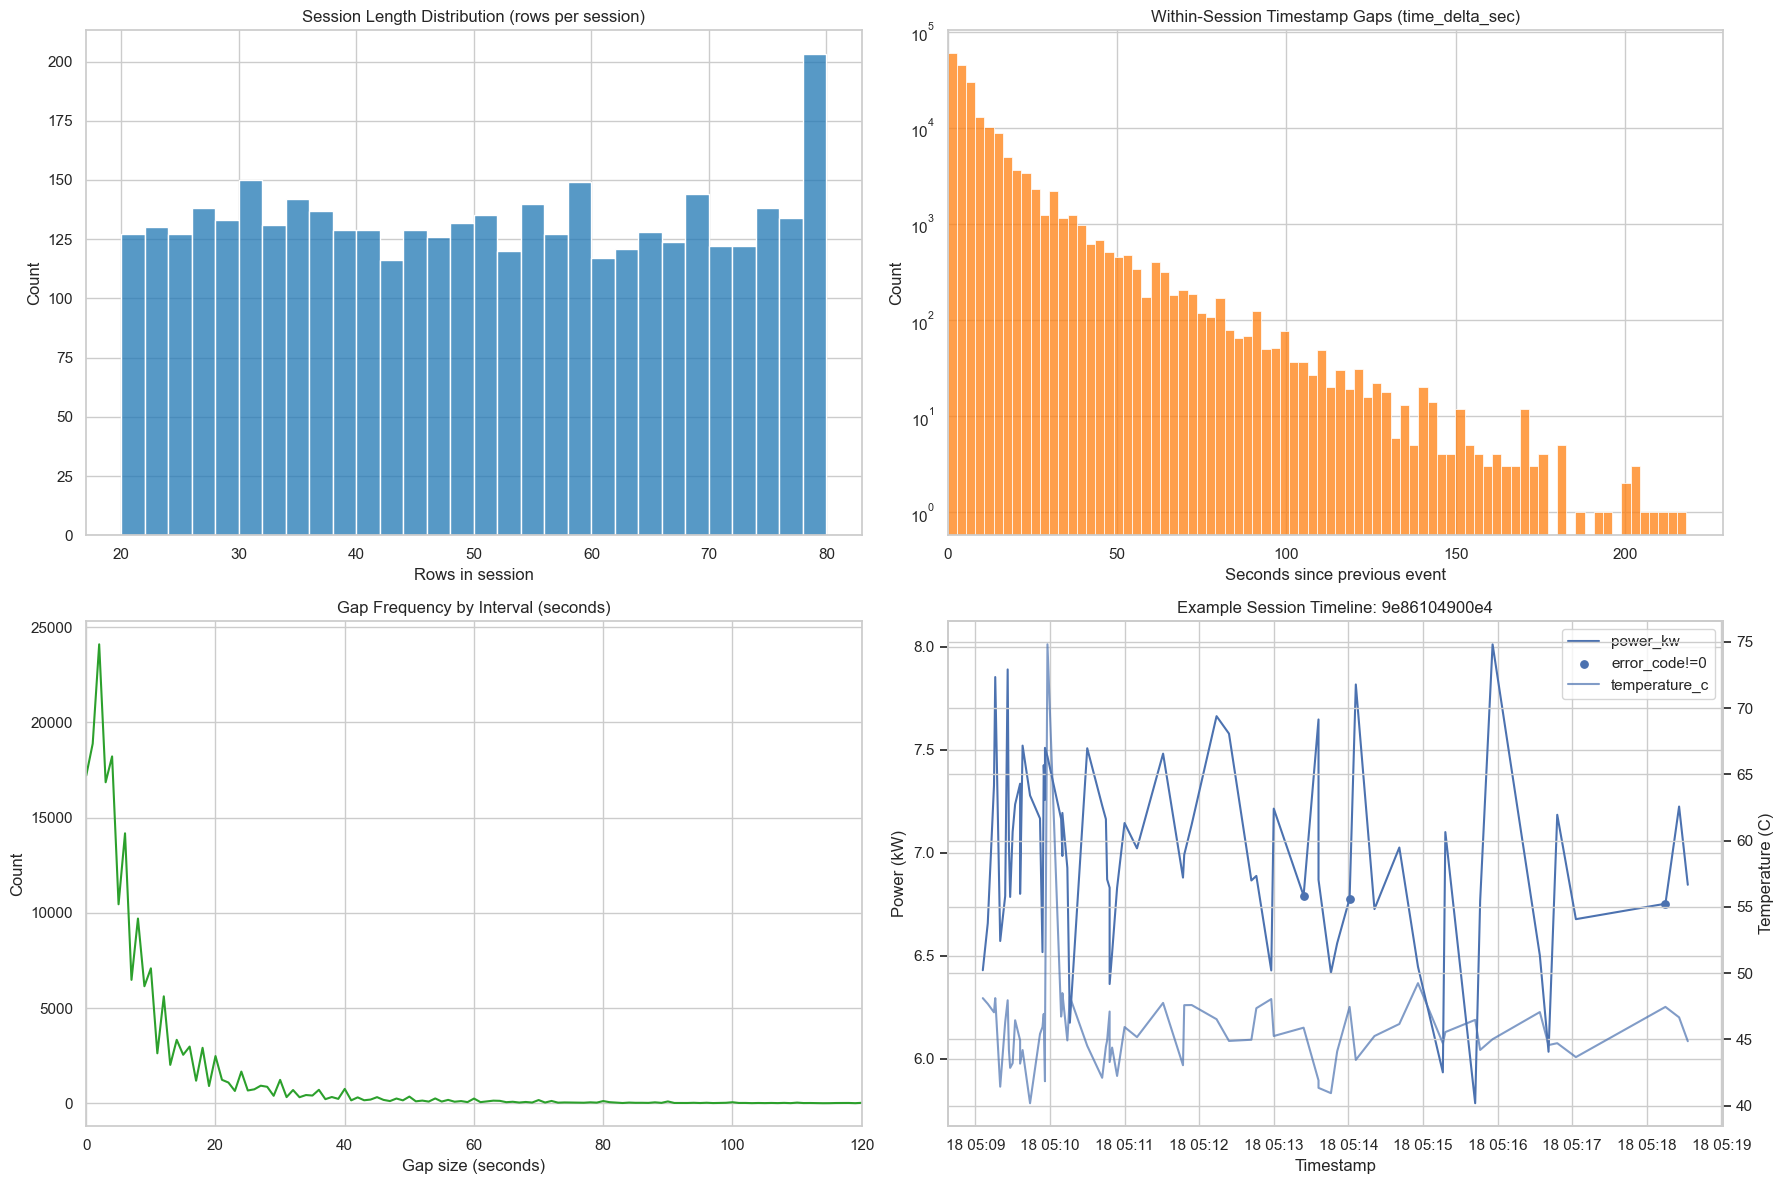

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.histplot(session_event_counts, bins=30, ax=axes[0, 0], color="tab:blue")
axes[0, 0].set_title("Session Length Distribution (rows per session)")
axes[0, 0].set_xlabel("Rows in session")

sns.histplot(df["time_delta_sec"].dropna(), bins=80, ax=axes[0, 1], color="tab:orange")
axes[0, 1].set_title("Within-Session Timestamp Gaps (time_delta_sec)")
axes[0, 1].set_xlabel("Seconds since previous event")
axes[0, 1].set_xlim(left=0)
axes[0, 1].set_yscale("log")

sns.lineplot(x=gap_freq.index, y=gap_freq.values, ax=axes[1, 0], color="tab:green")
axes[1, 0].set_title("Gap Frequency by Interval (seconds)")
axes[1, 0].set_xlabel("Gap size (seconds)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_xlim(0, min(120, max(int(gap_freq.index.max()), 1)))

# Example session timeline (power + temp)
ax = axes[1, 1]
ax.plot(example_session["timestamp"], example_session["power_kw"], label="power_kw")
ax.set_ylabel("Power (kW)")
ax.set_title(f"Example Session Timeline: {example_session_id}")
ax.set_xlabel("Timestamp")

ax_t = ax.twinx()
ax_t.plot(example_session["timestamp"], example_session["temperature_c"], alpha=0.7, label="temperature_c")
ax_t.set_ylabel("Temperature (C)")

error_points = example_session[example_session["has_error_code"]]
if not error_points.empty:
    ax.scatter(error_points["timestamp"], error_points["power_kw"], s=28, label="error_code!=0")

lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax_t.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.tight_layout()
plt.show()

## 13. EDA Findings Summary and Candidate Anomaly Heuristics

In [25]:
summary_metrics = pd.Series(
    {
        "rows": len(df),
        "stations": df["station_id"].nunique(),
        "sessions": df["session_id"].nunique(),
        "date_start": df["timestamp"].min(),
        "date_end": df["timestamp"].max(),
        "nonzero_error_rate_pct": df["has_error_code"].mean() * 100,
        "non_ok_message_rate_pct": (~df["message_is_ok_like"]).mean() * 100,
        "negative_power_rows": int((df["power_kw"] < 0).sum()),
        "high_temp_rows_p99": int((df["temperature_c"] > df["temperature_c"].quantile(0.99)).sum()),
    },
    name="value",
)

# Reuse bounds from earlier outlier summary
outlier_bounds = outlier_summary.set_index("feature")

a_flag = pd.DataFrame(index=df.index)
a_flag["error_code_nonzero"] = df["has_error_code"]
a_flag["message_not_ok_like"] = ~df["message_is_ok_like"]
a_flag["negative_power"] = df["power_kw"] < 0
a_flag["extreme_temp_iqr"] = (
    (df["temperature_c"] < outlier_bounds.loc["temperature_c", "lower_bound"]) |
    (df["temperature_c"] > outlier_bounds.loc["temperature_c", "upper_bound"])
)
a_flag["large_gap_p99"] = df["time_delta_sec"] > df["time_delta_sec"].quantile(0.99)
a_flag["power_vi_mismatch_p99"] = df["power_vi_diff_kw"].abs() > df["power_vi_diff_kw"].abs().quantile(0.99)

flag_rates = (a_flag.mean() * 100).sort_values(ascending=False).rename("flag_rate_pct").to_frame()
a_flag["any_candidate_flag"] = a_flag.any(axis=1)

display(summary_metrics.to_frame())
display(flag_rates)

,value
rows,199566
stations,20
sessions,4000
date_start,2024-01-01 00:05:42
date_end,2024-12-30 23:40:38
nonzero_error_rate_pct,0.5557
non_ok_message_rate_pct,0.5557
negative_power_rows,1103
high_temp_rows_p99,1988


,flag_rate_pct
extreme_temp_iqr,1.2392
power_vi_mismatch_p99,0.9987
large_gap_p99,0.9691
error_code_nonzero,0.5557
message_not_ok_like,0.5557
negative_power,0.5527


In [26]:
preview_cols = [
    "station_id",
    "timestamp",
    "session_id",
    "voltage",
    "current",
    "power_kw",
    "temperature_c",
    "duration_sec",
    "energy_kwh",
    "error_code",
    "message",
    "time_delta_sec",
    "power_vi_diff_kw",
]

candidate_preview = df.loc[a_flag["any_candidate_flag"], preview_cols].head(20)

print("Sample candidate rows (EDA heuristics only, not final anomaly labels):")
display(candidate_preview)

print("\nEDA notebook completed successfully ✅")

Sample candidate rows (EDA heuristics only, not final anomaly labels):


,station_id,timestamp,session_id,voltage,current,power_kw,temperature_c,duration_sec,energy_kwh,error_code,message,time_delta_sec,power_vi_diff_kw
30,STATION_7,2024-07-23 05:35:55,000560d7ab9d,232.5700,32.6400,-7.6100,45.4000,37,0.0782,0,OK,0.0000,-15.2011
43,STATION_7,2024-07-23 05:38:51,000560d7ab9d,235.4600,33.9500,8.0580,48.1500,58,0.1298,0,OK,67.0000,0.0641
54,STATION_14,2024-01-04 09:59:24,00071bb56210,235.3500,31.4000,7.4870,67.5300,34,0.0707,0,OK,2.0000,0.0970
68,STATION_14,2024-01-04 10:00:25,00071bb56210,229.6700,29.4400,6.8230,14.9900,24,0.0455,0,OK,3.0000,0.0615
89,STATION_14,2024-01-04 10:02:10,00071bb56210,226.7700,34.3600,7.8210,50.3500,7,0.0152,202,Unexpected reboot during active session,0.0000,0.0292
106,STATION_14,2024-01-04 10:06:37,00071bb56210,227.9600,29.0700,6.6250,49.7300,19,0.0350,0,OK,99.0000,-0.0018
205,STATION_18,2024-07-25 01:08:39,0035aeb5897a,225.6200,28.1500,6.3640,72.6400,21,0.0371,0,OK,5.0000,0.0128
222,STATION_2,2024-08-31 02:29:53,0046bf6f2636,238.0100,34.7900,8.3460,74.5200,44,0.1020,0,OK,2.0000,0.0656
242,STATION_2,2024-08-31 02:31:08,0046bf6f2636,237.0500,0.0000,7.5530,49.8400,20,0.0420,0,OK,0.0000,7.5530
246,STATION_2,2024-08-31 02:31:33,0046bf6f2636,231.5100,31.6900,7.2400,18.5000,20,0.0402,0,OK,17.0000,-0.0966



EDA notebook completed successfully ✅
